In [ ]:
import os, sys, random, warnings
import numpy as np
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import defaultdict
from pythermalcomfort.models import pmv_ppd
warnings.filterwarnings('ignore')

from models.dqn import DQN, DQNAgent
from models.ppo import PPOAgent
from models.sac import SACAgent
from models.td3 import TD3Agent

from models.model_saver_with_loader import load_agent

## Configuration
Edit paths and test settings here.

In [ ]:
# ── Model paths (update to match your saved_models/ filenames) ──────────────
# Accepts: exact path, bare filename, or tag prefix (finds latest match automatically).
DQN_PATH  = 'saved_models/dqn_model_no_adversary.pth'
RARL_PATH = 'saved_models/protagonist_model_with_energy_with_exaggerated5.pth'
PPO_PATH  = 'saved_models/ppo_clean_trial0_run0_20260326_145912.pth'
# RARL_PPO_PATH  = 'saved_models/rarl_ppo_protagonist4adversary_a.pth'
SAC_PATH  = 'saved_models/sac_clean_trial0_run0_20260330_122802.pth'
# TD3_PATH  = 'saved_models/td3_clean_trial0_run0_20260326_151751.pth'

# ── Test settings ────────────────────────────────────────────────────────────
EXAGGERATION_FRACTIONS = [0.0, 0.25, 0.50, 0.75, 1.0]   # paper Table I values
NUM_RUNS           = 1             # independent test runs per fraction
NUM_EPISODES       = 150           # episodes per run

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Using device: cuda


# Comparing DQN / PPO / SAC / TD3 model vs RARL model in Building HVAC Gymnasium Environment without visualised simulation (rendering) with exaggerated input

## Building HVAC Gymnasium Environment without visualised simulation (rendering) with exaggerated input

In [ ]:
class ExaggeratedBuildingEnv(gym.Env):
    def __init__(self, alpha=1, beta=1, EER=11, exaggeration_fraction=0.4):
        super(ExaggeratedBuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER

        # Fraction of users who exaggerate thermal discomfort.
        self.exaggeration_fraction = exaggeration_fraction

        self.room_width, self.room_height = 800, 600

        self.current_exaggeration_users = set()
        self.current_exaggeration_fraction = 0.0
        self.is_exaggeration = False

        self.user_feedback = 0.0
        self.nonadv_user_feedback = 0.0

        self.action_space = spaces.Discrete(9)

        low = np.array([-10.0, 0.0, -3.0], dtype=np.float32)
        high = np.array([50.0, 1.0, 3.0], dtype=np.float32)
        self.observation_space = spaces.Box(low, high, dtype=np.float32)

        self.time_step = 0
        self.max_steps = 48

        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()

        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        self.history = {
            'indoor_temp': [],
            'outdoor_temp': [],
            'hvac_power': [],
            'user_feedback': [],
            'nonadv_user_feedback': [],
            'occupancy': [],
            'time': [],
            'is_exaggeration': [],
            'exaggeration_fraction': []
        }

    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0

        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:
            occupancy = np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:
            occupancy = np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:
            occupancy = np.random.uniform(0.2, 0.5)
        else:
            occupancy = np.random.uniform(0.0, 0.1)

        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': random.randint(50, self.room_width - 50),
                'y': random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 1.5),
                'clo': np.random.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def apply_exaggeration(self, pmv):
        exaggeration_strength = 1.5

        abs_pmv = abs(pmv) 
        # Bell-shaped scale: 0 at pmv=0, peaks at pmv=±1.5, back to 0 at pmv=±3 
        # Normalised so the peak value = 1 (at abs_pmv = 1.5)
        scale = abs_pmv * (3.0 - abs_pmv) / 2.25 
        exaggerated = pmv + exaggeration_strength * np.sign(pmv) * scale + np.random.normal(0.0, 0.08) 
        return float(np.clip(exaggerated, -3.0, 3.0))

    def generate_user_feedback(self):
        if self.num_users == 0:
            self.current_exaggeration_users = set()
            self.current_exaggeration_fraction = 0.0
            self.is_exaggeration = False
            self.nonadv_user_feedback = 0.0
            return 0.0

        num_exaggeration = int(self.exaggeration_fraction * self.num_users)

        if num_exaggeration > 0:
            self.current_exaggeration_users = set(
                random.sample(range(self.num_users), num_exaggeration)
            )
        else:
            self.current_exaggeration_users = set()

        self.current_exaggeration_fraction = (
            len(self.current_exaggeration_users) / self.num_users
            if self.num_users > 0 else 0.0
        )
        self.is_exaggeration = len(self.current_exaggeration_users) > 0

        clean_pmv_values = []
        final_pmv_values = []

        for idx, user in enumerate(self.users):
            met = user['met']
            clo = user['clo']

            if self.indoor_temp > 26:
                clo = max(0.5, clo - 0.1)
            elif self.indoor_temp < 20:
                clo = min(1.0, clo + 0.1)

            pmv = float(self.calculate_pmv(met, clo))
            clean_pmv_values.append(pmv)

            if idx in self.current_exaggeration_users:
                final_pmv_values.append(self.apply_exaggeration(pmv))
            else:
                final_pmv_values.append(pmv)

        self.nonadv_user_feedback = float(np.mean(clean_pmv_values))
        final_feedback = float(np.mean(final_pmv_values))
        return float(np.clip(final_feedback, -3.0, 3.0))

    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp
        tr = tdb
        rh = 50.0
        v = 0.1

        pmv_result = pmv_ppd(
            tdb=tdb,
            tr=tr,
            vr=v,
            rh=rh,
            met=met,
            clo=clo,
            standard='ASHRAE'
        )
        return pmv_result['pmv']

    def step(self, action, adversary_action=None):
        if adversary_action is not None:
            self.setpoint_temp = 22 + action

            base_influence = (adversary_action - 4) * 0.5

            if self.current_exaggeration_fraction > 0:
                if abs(self.user_feedback) > 1.0:
                    base_influence *= 1.2
                if self.occupancy_level > 0.7:
                    base_influence *= 1.5

            self.setpoint_temp += base_influence
        else:
            self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER

        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        solar_gain = np.sin((time_of_day - 6) * np.pi / 12) * 0.05
        solar_gain = max(0.0, solar_gain)

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5

        self.indoor_temp += outdoor_influence + hvac_influence + solar_gain

        self.time_step += 1
        done = self.time_step >= self.max_steps

        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()

        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)

        reward = reward / 10.0

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['nonadv_user_feedback'].append(self.nonadv_user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)
        self.history['is_exaggeration'].append(self.is_exaggeration)
        self.history['exaggeration_fraction'].append(self.current_exaggeration_fraction)

        state = np.array(
            [self.outdoor_temp, self.occupancy_level, self.user_feedback],
            dtype=np.float32
        )

        return state, reward, done, {}

    def get_pmv_wo_adv(self):
        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)
        else:
            comfort_penalty = abs(self.nonadv_user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)

        return reward / 10.0

    def reset(self):
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.hvac_power = 0.0

        self.is_exaggeration = False
        self.current_exaggeration_users = set()
        self.current_exaggeration_fraction = 0.0
        self.nonadv_user_feedback = 0.0

        self.user_feedback = self.generate_user_feedback()

        for key in self.history.keys():
            self.history[key] = []

        state = np.array(
            [self.outdoor_temp, self.occupancy_level, self.user_feedback],
            dtype=np.float32
        )

        return state

    def render(self):
        pass

## Comparing RL baselines vs RARL model in Building HVAC Gymnasium Environment without visualised simulation (rendering) with exaggerated input
**IMPORTANT NOTE**:  
- RARL HIL is trained in an adversarial/irrational/exaggerated input-free offline setting, with *simulated* adversarial/irrational/exaggerated input from the adversary agent, then deployed in a online setting with adversarial/irrational/exaggerated input
- RL agents/baselines are trained in an adversarial/irrational/exaggerated input-free offline setting, then deployed in a online setting with adversarial/irrational/exaggerated input

In [ ]:
def eval_episode(env, policy_net, device):
    """Run one episode with a fixed policy_net (no gradient, no replay)."""
    state = env.reset()
    ep_reward, done = 0.0, False
    while not done:
        t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            action = policy_net(t).max(1).indices.item()
        state, r, done, _ = env.step(action)
        ep_reward += r
    return ep_reward


def run_tests(policy_net, env_class, exaggeration_fraction, device,
              num_runs=3, num_episodes=150):
    """Evaluate policy_net for num_runs * num_episodes episodes."""
    env = env_class(exaggeration_fraction=exaggeration_fraction)
    all_rewards = []
    for run in range(num_runs):
        run_rewards = [eval_episode(env, policy_net, device) for _ in range(num_episodes)]
        all_rewards.append(run_rewards)
        print(f'  run {run+1}/{num_runs}  avg={np.mean(run_rewards):.4f}')
    return np.array(all_rewards)


def test_all_ratios(agents_dict, ratios, device, num_runs=3, num_episodes=150):
    """
    agents_dict : {label: policy_net_module}
    Returns     : {label: {ratio: np.array(num_runs, num_episodes)}}
    """
    results = {label: {} for label in agents_dict}
    for ratio in ratios:
        print(f'\n─── Exaggeration ratio: {ratio} ───')
        for label, net in agents_dict.items():
            print(f'  [{label}]')
            results[label][ratio] = run_tests(net, ExaggeratedBuildingEnv, ratio, device,
                                              num_runs=num_runs, num_episodes=num_episodes)
    return results


def plot_results(results, ratios, title='Performance vs Exaggeration Ratio'):
    colors = {'DQN':'purple','RARL':'navy','PPO':'steelblue','RARL_PPO':'deepskyblue',
              'SAC':'darkorange','TD3':'forestgreen'}
    fig, axes = plt.subplots(1, len(ratios), figsize=(7*len(ratios), 5), sharey=True)
    if len(ratios) == 1: axes = [axes]
    fig.suptitle(title, fontsize=14)
    for ax, ratio in zip(axes, ratios):
        for label, ratio_results in results.items():
            data = ratio_results[ratio]
            m = np.mean(data, axis=0)
            ax.plot(m, label=label, color=colors.get(label), linewidth=2)
            ax.fill_between(range(len(m)), np.min(data,axis=0), np.max(data,axis=0),
                            color=colors.get(label), alpha=0.15)
        ax.set_title(f'Exaggeration ratio = {ratio}', fontsize=12)
        ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def print_statistics(results, ratios):
    print('\n=== Average Reward Statistics ===')
    for ratio in ratios:
        print(f'\n  Exaggeration ratio: {ratio}')
        rarl_avg = np.mean(results['RARL'][ratio]) if 'RARL' in results else None
        for label, ratio_results in results.items():
            avg = np.mean(ratio_results[ratio])
            std = np.std([np.mean(r) for r in ratio_results[ratio]])
            imp = f'  ({((avg - rarl_avg) / abs(rarl_avg) * 100):+.1f}% vs RARL)'                   if rarl_avg is not None and label != 'RARL' else ''
            print(f'    {label:6s}: {avg:.4f} ± {std:.4f}{imp}')

print('Test helpers defined.')

Test helpers defined.


## Load trained models

In [38]:
n_obs, n_act = 3, 9

# DQN baseline
dqn_agent = DQNAgent(n_observations=n_obs, n_actions=n_act, device=device)
load_agent(dqn_agent, DQN_PATH)

# RARL protagonist (saved as raw DQN policy_net state_dict)
rarl_agent = DQNAgent(n_observations=n_obs, n_actions=n_act, device=device)
load_agent(rarl_agent, RARL_PATH)

# PPO baseline
ppo_agent = PPOAgent(n_observations=n_obs, n_actions=n_act, device=device)
load_agent(ppo_agent, PPO_PATH)

# RARL PPO protagonist
# rarl_ppo_agent = PPOAgent(n_observations=n_obs, n_actions=n_act, device=device)
# load_agent(rarl_ppo_agent, RARL_PPO_PATH)

# SAC baseline
sac_agent = SACAgent(n_observations=n_obs, n_actions=n_act, device=device)
load_agent(sac_agent, SAC_PATH)

# td3_agent = TD3Agent(n_observations=n_obs, n_actions=n_act, device=device)
# load_agent(td3_agent, TD3_PATH)

# Map each agent to the policy_net used during inference
# (all expose .policy_net; test loop calls .max(1).indices)
AGENTS = {
    'DQN':  dqn_agent.policy_net,
    'RARL': rarl_agent.policy_net,
    'PPO':  ppo_agent.policy_net,
    # 'RARL_PPO': rarl_ppo_agent.policy_net,
    'SAC':  sac_agent.policy_net,
    # 'TD3':  td3_agent.policy_net,
}
print('All models loaded.')

  [loaded] saved_models/dqn_model_no_adversary.pth


  [loaded] saved_models/protagonist_model_with_energy_with_exaggerated5.pth
  [loaded] saved_models/ppo_clean_trial0_run0_20260326_145912.pth
  [loaded] saved_models/sac_clean_trial0_run0_20260330_122802.pth
All models loaded.


## Run evaluation

In [ ]:
results = test_all_ratios(
    AGENTS,
    ratios      = EXAGGERATION_FRACTIONS,
    device      = device,
    num_runs    = NUM_RUNS,
    num_episodes= NUM_EPISODES,
)


─── Adversarial ratio: 0.0 ───
  [DQN]


  run 1/1  avg=-0.1222
  [RARL]
  run 1/1  avg=-0.1304
  [PPO]
  run 1/1  avg=-0.1494
  [SAC]
  run 1/1  avg=-0.0877

─── Adversarial ratio: 0.25 ───
  [DQN]
  run 1/1  avg=-0.2295
  [RARL]
  run 1/1  avg=-0.1747
  [PPO]
  run 1/1  avg=-0.2078
  [SAC]
  run 1/1  avg=-0.1422

─── Adversarial ratio: 0.5 ───
  [DQN]
  run 1/1  avg=-0.3351
  [RARL]
  run 1/1  avg=-0.2192
  [PPO]
  run 1/1  avg=-0.2713
  [SAC]
  run 1/1  avg=-0.2262

─── Adversarial ratio: 0.75 ───
  [DQN]
  run 1/1  avg=-0.4199
  [RARL]
  run 1/1  avg=-0.2667
  [PPO]
  run 1/1  avg=-0.3291
  [SAC]
  run 1/1  avg=-0.2879

─── Adversarial ratio: 1.0 ───
  [DQN]
  run 1/1  avg=-0.5067
  [RARL]
  run 1/1  avg=-0.3177
  [PPO]
  run 1/1  avg=-0.3910
  [SAC]
  run 1/1  avg=-0.3389


## Results


=== Average Reward Statistics ===

  Adversarial ratio: 0.0
    DQN   : -0.1222 ± 0.0000  (+6.3% vs RARL)
    RARL  : -0.1304 ± 0.0000
    PPO   : -0.1494 ± 0.0000  (-14.6% vs RARL)
    SAC   : -0.0877 ± 0.0000  (+32.8% vs RARL)

  Adversarial ratio: 0.25
    DQN   : -0.2295 ± 0.0000  (-31.4% vs RARL)
    RARL  : -0.1747 ± 0.0000
    PPO   : -0.2078 ± 0.0000  (-19.0% vs RARL)
    SAC   : -0.1422 ± 0.0000  (+18.6% vs RARL)

  Adversarial ratio: 0.5
    DQN   : -0.3351 ± 0.0000  (-52.9% vs RARL)
    RARL  : -0.2192 ± 0.0000
    PPO   : -0.2713 ± 0.0000  (-23.8% vs RARL)
    SAC   : -0.2262 ± 0.0000  (-3.2% vs RARL)

  Adversarial ratio: 0.75
    DQN   : -0.4199 ± 0.0000  (-57.5% vs RARL)
    RARL  : -0.2667 ± 0.0000
    PPO   : -0.3291 ± 0.0000  (-23.4% vs RARL)
    SAC   : -0.2879 ± 0.0000  (-8.0% vs RARL)

  Adversarial ratio: 1.0
    DQN   : -0.5067 ± 0.0000  (-59.5% vs RARL)
    RARL  : -0.3177 ± 0.0000
    PPO   : -0.3910 ± 0.0000  (-23.1% vs RARL)
    SAC   : -0.3389 ± 0.0000  (-6

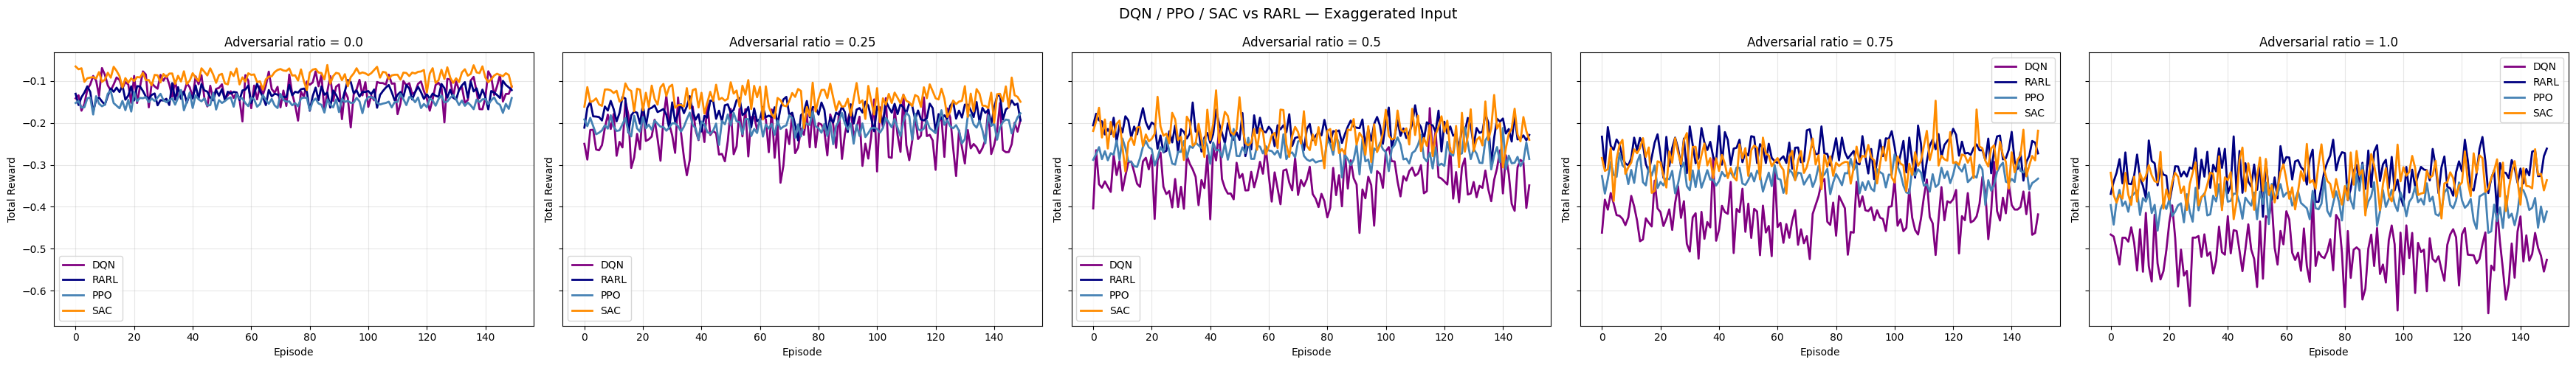

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/sit

In [ ]:
print_statistics(results, EXAGGERATION_FRACTIONS)
plot_results(results, EXAGGERATION_FRACTIONS,
             title='DQN / PPO / SAC vs RARL — Exaggerated Input')